# MT²-CSD Analysis — LLM Stance Detection

Evaluates models on the **MT²-CSD** test set (2,371 documents, 3 classes: FAVOR / AGAINST / NONE).  
Targets: **Bitcoin, Tesla, SpaceX, Biden, Trump** (Post-T excluded — not in our test set).

**Primary metric**: 3-class Macro F1 — consistent with EZStance / SemEval analysis in this paper.  
**Secondary metric**: F_avg = (F_favor + F_against) / 2 — paper metric, for comparison against Table IX baselines.

**Paper baselines** (Table IX, *"Only considering individual posts/comments"* section, 5-target avg excluding Post-T):

| Method | Bitcoin | Tesla | SpaceX | Biden | Trump | 5T Avg |
|--------|---------|-------|--------|-------|-------|--------|
| TTS (best) | 50.88 | 43.85 | 47.50 | 29.00 | 42.10 | **42.67** |
| KPT        | 50.34 | 43.11 | 47.47 | 28.90 | 41.87 | 42.34 |
| BERT       | 50.99 | 43.85 | 45.88 | 26.65 | 42.45 | 41.96 |

> 3-class F1 baselines from the paper are **not available** (paper only reports 2-class F_avg). Conversation-history baselines excluded — our models use individual posts/comments only.  
> F_avg is computed **per target first, then macro-averaged across 5 targets** — matching the paper's methodology.

## Step 1: Imports

In [1]:
import os
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

## Step 2: Config

In [2]:
_candidates = [Path("../data_out/stance/mtcsd_test_results"), Path("data_out/stance/mtcsd_test_results")]
RESULTS_DIR = next(p for p in _candidates if p.exists())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

_gold_candidates = [Path("../data_in/mtcsd/mtcsd_test.csv"), Path("data_in/mtcsd/mtcsd_test.csv")]
GOLD_PATH = next(p for p in _gold_candidates if p.exists())

PREFIX  = "GenAIStanceOneShot_2371_mtcsd_test_"
CLASSES = ["FAVOR", "AGAINST", "NONE"]
TARGET_ORDER = ["Bitcoin", "Tesla", "SpaceX", "Biden", "Trump"]

PROMPT_ORDER = [
    "default_no_label_definitions", "default", "task_definition",
    "question", "cot", "task_definition_scale",
    "few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15",
]
PROMPT_LABELS = {
    "default_no_label_definitions": "No-def",  "default": "Default",
    "task_definition": "Task-def",              "question": "Question",
    "cot": "CoT",                               "task_definition_scale": "Scale",
    "few_shot_3": "3R",  "few_shot_6": "6R",  "few_shot_9": "9R",
    "few_shot_12": "12R", "few_shot_15": "15R",
}
ZERO_SHOT  = ["default_no_label_definitions","default","task_definition","question","cot","task_definition_scale"]
RANDOM_ICL = ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"]

CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

# Paper baselines — individual section, F_avg, 5-target avg (Post-T excluded)
PAPER_FAVG = {
    "TTS (best indiv.)": 42.67 / 100,
    "KPT":               42.34 / 100,
    "BERT (indiv.)":     41.96 / 100,
}
PAPER_PER_TARGET = {
    "TTS":  {"Bitcoin":50.88/100,"Tesla":43.85/100,"SpaceX":47.50/100,"Biden":29.00/100,"Trump":42.10/100},
    "KPT":  {"Bitcoin":50.34/100,"Tesla":43.11/100,"SpaceX":47.47/100,"Biden":28.90/100,"Trump":41.87/100},
    "BERT": {"Bitcoin":50.99/100,"Tesla":43.85/100,"SpaceX":45.88/100,"Biden":26.65/100,"Trump":42.45/100},
}

GOLD_DIST = {"FAVOR": 466/2371, "AGAINST": 724/2371, "NONE": 1181/2371}

CANON_MAP = {"PRO": "FAVOR", "NEUTRAL": "NONE", "UNCLEAR": "NONE"}
def canon(s):
    s = str(s).upper().strip()
    return CANON_MAP.get(s, s)

print("Targets:", TARGET_ORDER)
print("Gold dist:", {k: f"{v:.3f}" for k,v in GOLD_DIST.items()})

RESULTS_DIR: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/mtcsd_test_results
Targets: ['Bitcoin', 'Tesla', 'SpaceX', 'Biden', 'Trump']
Gold dist: {'FAVOR': '0.197', 'AGAINST': '0.305', 'NONE': '0.498'}


## Step 3: Load LLM Results

- **3-class Macro F1** — primary metric (global, consistent with EZStance / SemEval)  
- **F_avg** — paper metric: per-target (F_favor+F_against)/2, then macro-averaged across 5 targets

In [3]:
llm_rows = []

for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem  = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"]  = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue

    yt, yp = df["original_stance"].tolist(), df["predicted_stance"].tolist()

    # 3-class Macro F1 (primary — global)
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yp, labels=CLASSES, zero_division=0)
    macro_f1 = f1.mean()

    # F_avg — per-target then average (paper methodology)
    per_tgt_favg = []
    for t in TARGET_ORDER:
        sub = df[df["query"].astype(str).str.strip() == t]
        if len(sub) == 0:
            continue
        _, _, ft, _ = precision_recall_fscore_support(
            sub["original_stance"].tolist(), sub["predicted_stance"].tolist(),
            labels=CLASSES, zero_division=0)
        per_tgt_favg.append((ft[0] + ft[1]) / 2)
    f_avg = np.mean(per_tgt_favg) if per_tgt_favg else float("nan")

    vc = pd.Series(yp).value_counts()
    llm_rows.append({
        "model": model, "prompt": prompt,
        "3class_macro_f1": macro_f1, "f_avg": f_avg,
        "f_favor":   f1[0], "f_against": f1[1], "f_none": f1[2],
        "p_favor":  prec[0], "p_against": prec[1], "p_none": prec[2],
        "r_favor":   rec[0], "r_against":  rec[1], "r_none":  rec[2],
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
        "n_valid": len(df),
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Loaded {len(llm_df)} rows | {llm_df['model'].nunique()} models")
print("Models:", sorted(llm_df["model"].unique()))
llm_df[["model","prompt","3class_macro_f1","f_avg","f_favor","f_against","f_none"]].head(6)

Loaded 154 rows | 14 models
Models: ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']


,model,prompt,3class_macro_f1,f_avg,f_favor,f_against,f_none
0,DeepSeek-R1-Distill-Llama-8B,cot,0.556782,0.453475,0.477679,0.541056,0.651613
1,DeepSeek-R1-Distill-Llama-8B,default,0.519591,0.403783,0.441978,0.459750,0.657045
2,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,0.524551,0.427189,0.446208,0.529878,0.597566
3,DeepSeek-R1-Distill-Llama-8B,few_shot_12,0.552651,0.430166,0.476836,0.510878,0.670237
4,DeepSeek-R1-Distill-Llama-8B,few_shot_15,0.545297,0.430840,0.445961,0.517725,0.672205
5,DeepSeek-R1-Distill-Llama-8B,few_shot_3,0.540769,0.405495,0.444976,0.492679,0.684652


## Step 4: Helper — ordered model list

In [4]:
def _ordered_models(df, by="3class_macro_f1"):
    return df.groupby("model")[by].mean().sort_values(ascending=False).index.tolist()

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS[p] for p in available_prompts]

# Separator x-position between zero-shot and ICL
if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    ICL_SEP = (available_prompts.index("task_definition_scale") +
               available_prompts.index("few_shot_3")) / 2
else:
    ICL_SEP = None

def add_icl_sep(ax):
    if ICL_SEP is None:
        return
    ax.axvline(ICL_SEP, color="grey", linestyle=":", linewidth=1)
    bounds = [-0.5, ICL_SEP, len(available_prompts) - 0.5]
    for gi, lbl in enumerate(["Zero-shot", "Random ICL"]):
        mid = (bounds[gi] + bounds[gi+1]) / 2
        ax.text(mid, -0.08, lbl, ha="center", fontsize=7.5, color="grey",
                transform=ax.get_xaxis_transform())

print("Prompts:", available_prompts)
print("ICL separator at x =", ICL_SEP)

Prompts: ['default_no_label_definitions', 'default', 'task_definition', 'question', 'cot', 'task_definition_scale', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15']
ICL separator at x = 5.5


## Step 5: Chart A — 3-class Macro F1 by Prompt (Primary Metric)

No paper baseline available for 3-class F1 on MT²-CSD — our models only.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19558/2271945512.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))


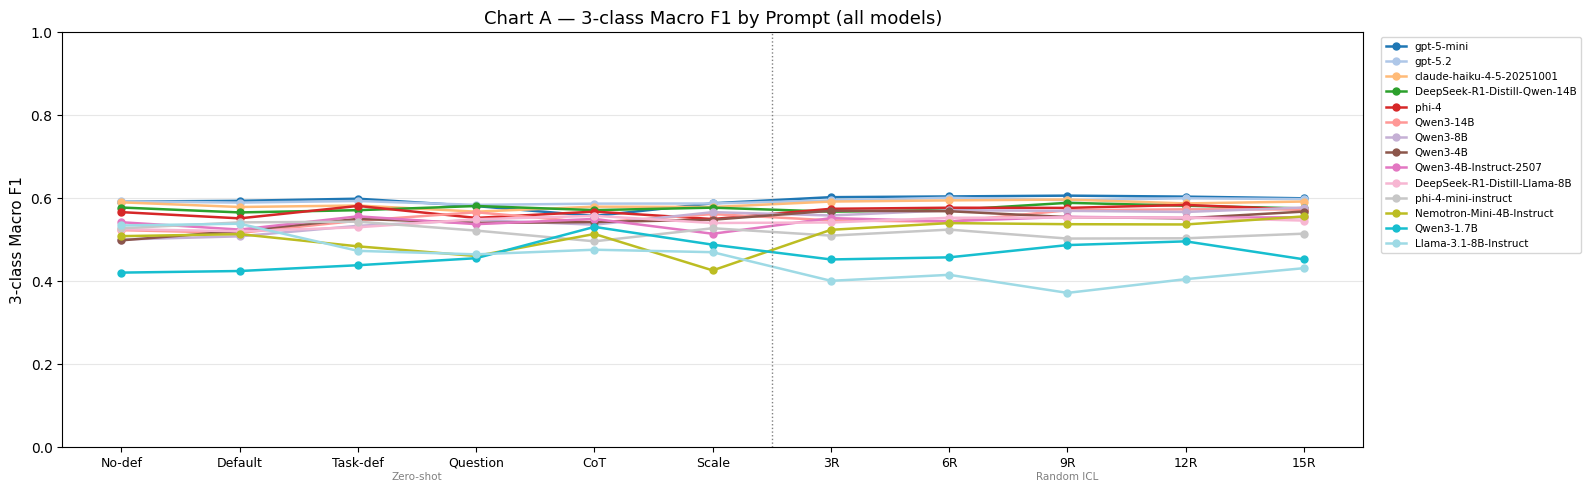

In [5]:
models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))

fig, ax = plt.subplots(figsize=(max(16, len(available_prompts) * 1.2), 5))
for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y   = [mdf.loc[p, "3class_macro_f1"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5, label=model, color=cmap(i))

add_icl_sep(ax)
ax.set_ylim(0, 1)
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Chart A — 3-class Macro F1 by Prompt (all models)", fontsize=13)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 6: Chart B — F_avg by Prompt vs Paper Baselines (Paper Metric)

F_avg = (F_favor + F_against) / 2, computed per target then macro-averaged. Paper baselines from Table IX individual section, 5-target avg.

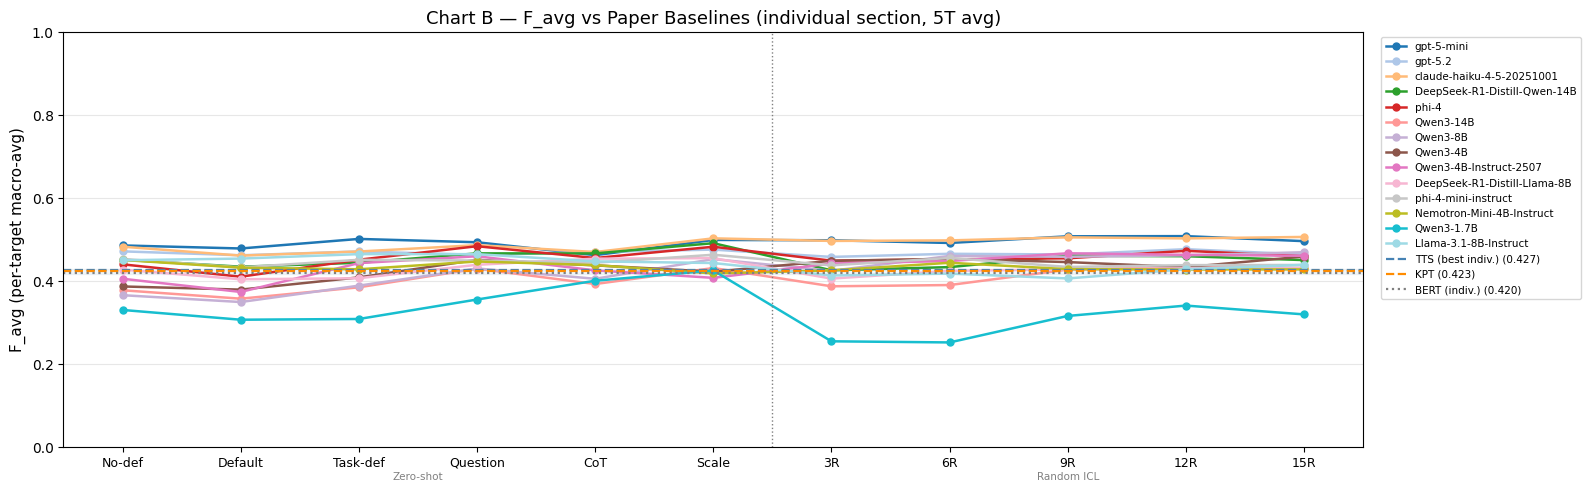

In [6]:
fig, ax = plt.subplots(figsize=(max(16, len(available_prompts) * 1.2), 5))
for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y   = [mdf.loc[p, "f_avg"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5, label=model, color=cmap(i))

bl_styles = [
    ("TTS (best indiv.)", "steelblue", "--"),
    ("KPT",               "darkorange","--"),
    ("BERT (indiv.)",     "grey",      ":"),
]
for name, col, ls in bl_styles:
    val = PAPER_FAVG[name]
    ax.axhline(val, color=col, linestyle=ls, linewidth=1.6, label=f"{name} ({val:.3f})")

vals = list(PAPER_FAVG.values())
ax.axhspan(min(vals)-0.003, max(vals)+0.003, alpha=0.07, color="steelblue")

add_icl_sep(ax)
ax.set_ylim(0, 1)
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("F_avg (per-target macro-avg)", fontsize=11)
ax.set_title("Chart B — F_avg vs Paper Baselines (individual section, 5T avg)", fontsize=13)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 7: Numerical Summary — 3-class F1 and F_avg

In [7]:
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f3    =("3class_macro_f1","mean"), best_f3    =("3class_macro_f1","max"),
        std_f3     =("3class_macro_f1","std"),
        mean_f_avg =("f_avg",          "mean"), best_f_avg =("f_avg",          "max"),
        mean_ffav  =("f_favor",        "mean"), mean_fagn  =("f_against",      "mean"),
        mean_fnon  =("f_none",         "mean"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)

hdr = f"{'Model':<38} {'F3 mean':>8} {'F3 best':>8} {'F3 std':>7} {'Favg mean':>10} {'Favg best':>10} {'F-FAV':>7} {'F-AGN':>7} {'F-NON':>7}"
print(hdr); print("─"*len(hdr))
for _, r in summary.iterrows():
    print(f"{r['model']:<38} {r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {r['std_f3']:>7.4f} "
          f"{r['mean_f_avg']:>10.4f} {r['best_f_avg']:>10.4f} "
          f"{r['mean_ffav']:>7.4f} {r['mean_fagn']:>7.4f} {r['mean_fnon']:>7.4f}")
print("─"*len(hdr))
print("\nPaper F_avg baselines (individual section, 5T avg):")
for k,v in PAPER_FAVG.items(): print(f"  {k:<30} {v:.4f}")

Model                                   F3 mean  F3 best  F3 std  Favg mean  Favg best   F-FAV   F-AGN   F-NON
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5-mini                               0.5926   0.6054  0.0143     0.4926     0.5078  0.4920  0.6187  0.6671
gpt-5.2                                  0.5921   0.6003  0.0056     0.4671     0.4764  0.4749  0.6137  0.6878
claude-haiku-4-5-20251001                0.5847   0.5960  0.0088     0.4890     0.5059  0.5108  0.6002  0.6431
DeepSeek-R1-Distill-Qwen-14B             0.5746   0.5881  0.0069     0.4528     0.4908  0.4788  0.5652  0.6798
phi-4                                    0.5677   0.5830  0.0122     0.4553     0.4835  0.4582  0.5820  0.6630
Qwen3-14B                                0.5502   0.5724  0.0197     0.4036     0.4335  0.4360  0.5126  0.7021
Qwen3-8B                                 0.5479   0.5768  0.0262     0.4239     0.4690  0.4384  0.5303  0.6749
Q

## Step 8: Per-class Precision / Recall / F1 — by Prompt

3 × 3 grid: rows = FAVOR / AGAINST / NONE, columns = Precision / Recall / F1.

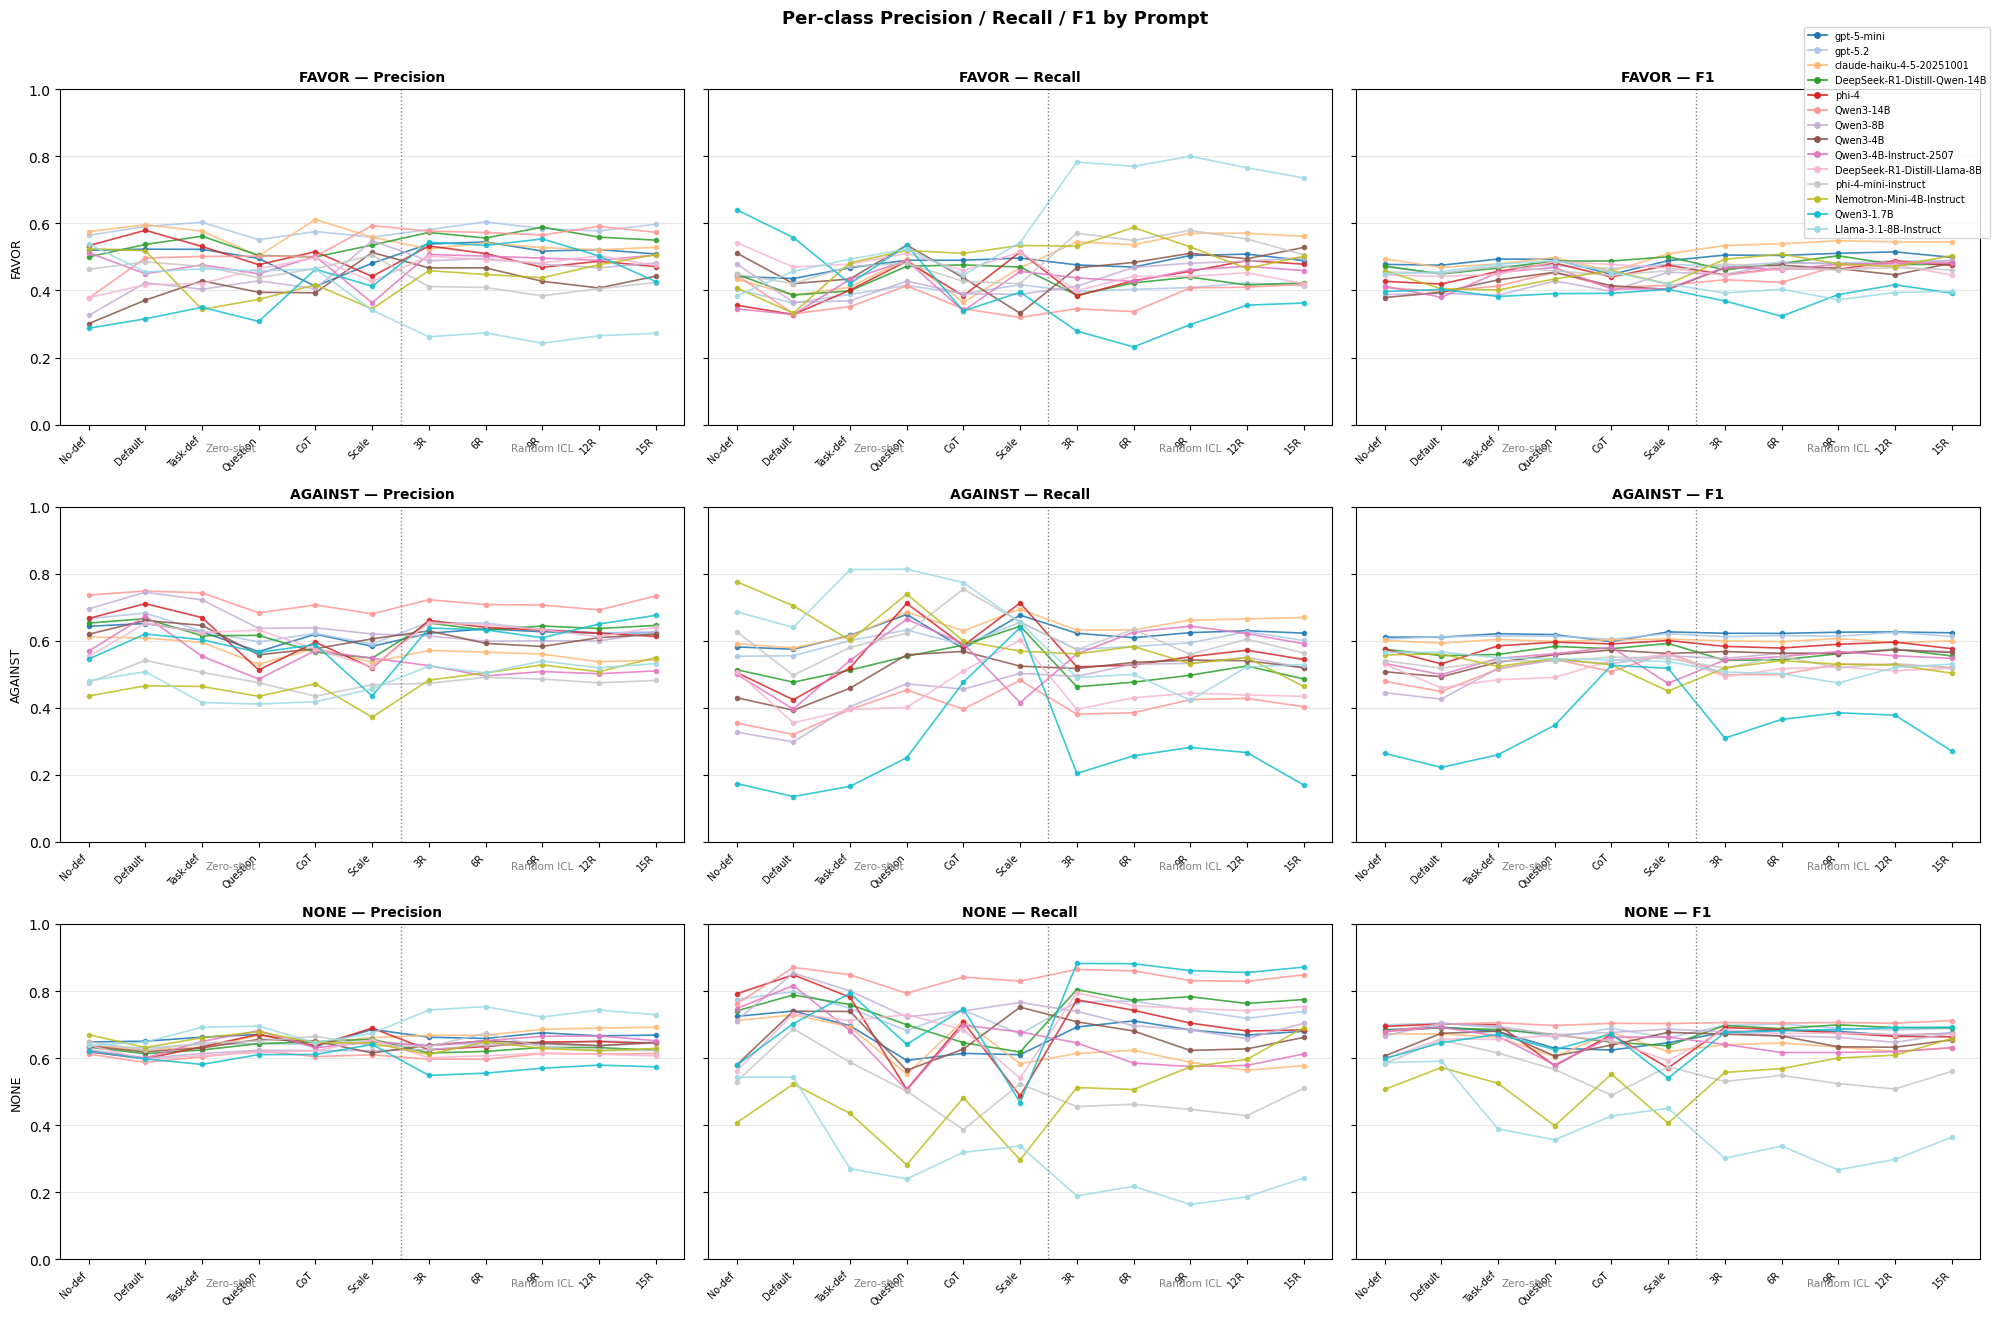

In [8]:
METRICS = [("p","Precision"),("r","Recall"),("f","F1")]
fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (mk, ml) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{mk}_{cls.lower()}"
        for i, model in enumerate(models):
            mdf = llm_df[llm_df["model"]==model].set_index("prompt")
            y   = [mdf.loc[p, col_name] if p in mdf.index else float("nan") for p in available_prompts]
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=model, color=cmap(i), alpha=0.85)
        add_icl_sep(ax)
        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {ml}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0: ax.set_ylabel(cls, fontsize=9)

handles = [mlines.Line2D([],[],color=cmap(i),marker="o",linewidth=1.2,markersize=4,label=m)
           for i,m in enumerate(models)]
fig.legend(handles=handles, fontsize=7, loc="upper right", bbox_to_anchor=(1.0,1.0))
fig.suptitle("Per-class Precision / Recall / F1 by Prompt", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## Step 9: Per-class F1 — Model Comparison (mean ± std across prompts)

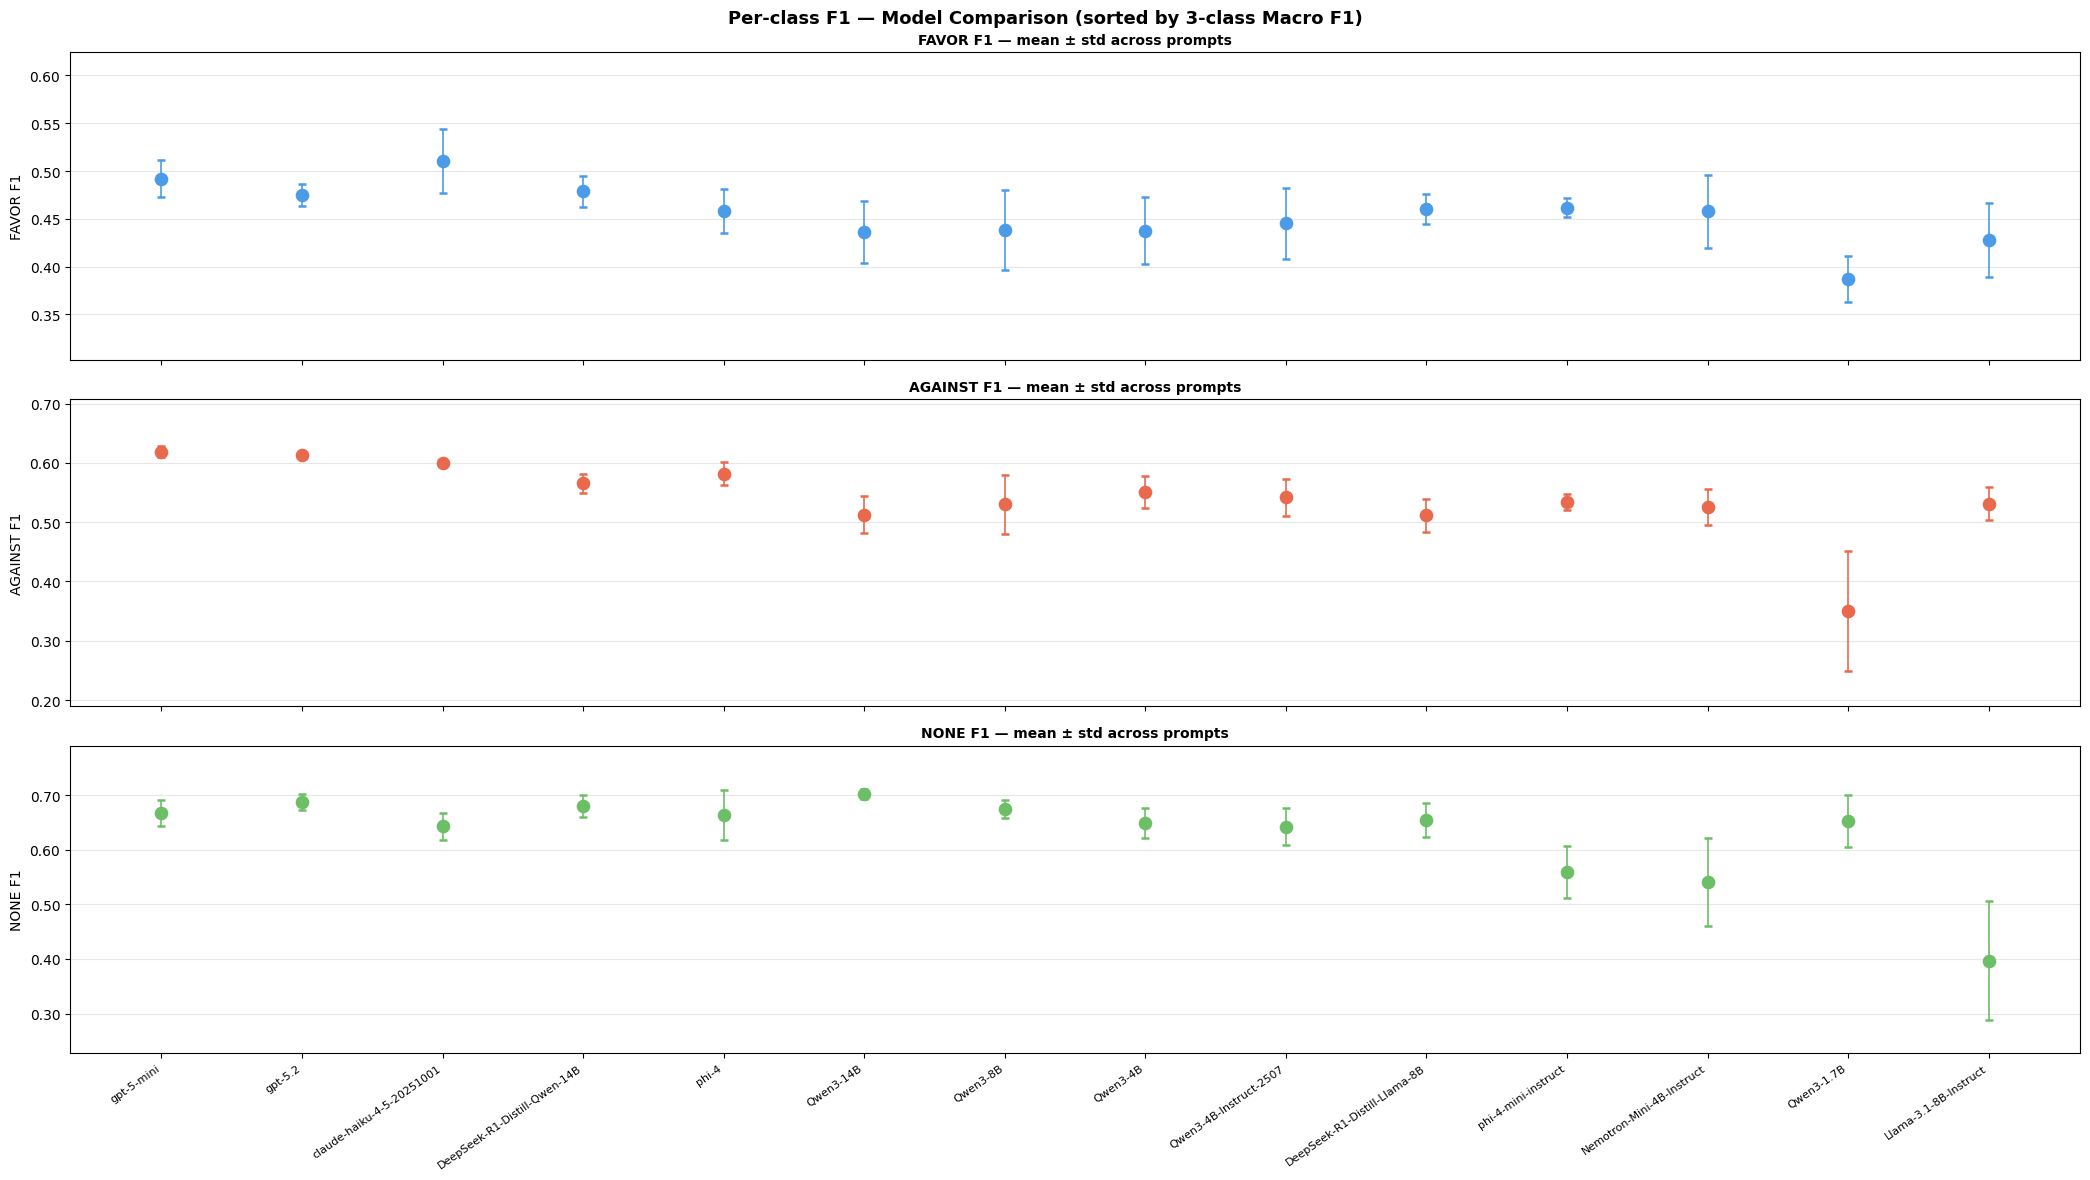

In [9]:
model_order = _ordered_models(llm_df)
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(model_order)*1.5), 12), sharex=True)
for row_idx, cls in enumerate(CLASSES):
    ax    = axes[row_idx]
    col   = f"f_{cls.lower()}"
    color = CLASS_COLORS[cls]
    means = np.array([llm_df[llm_df["model"]==m][col].mean() for m in model_order])
    stds  = np.array([llm_df[llm_df["model"]==m][col].std()  for m in model_order])
    for i,(mv,sv) in enumerate(zip(means,stds)):
        ax.errorbar(x[i], mv, yerr=sv, fmt="o", markersize=8,
                    color=color, markeredgecolor=color, markeredgewidth=1.8,
                    ecolor=color, elinewidth=1.2, capsize=3, zorder=3)
    ax.set_ylabel(f"{cls} F1", fontsize=10)
    lo = max(0,(means-stds).min()-0.06); hi = min(1,(means+stds).max()+0.08)
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — mean ± std across prompts", fontsize=10, fontweight="bold")

axes[-1].set_xticks(x); axes[-1].set_xticklabels(model_order, fontsize=8, rotation=35, ha="right")
fig.suptitle("Per-class F1 — Model Comparison (sorted by 3-class Macro F1)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 10: Precision vs Recall Scatter — per class

One panel per class. Each point = one model × prompt combination.

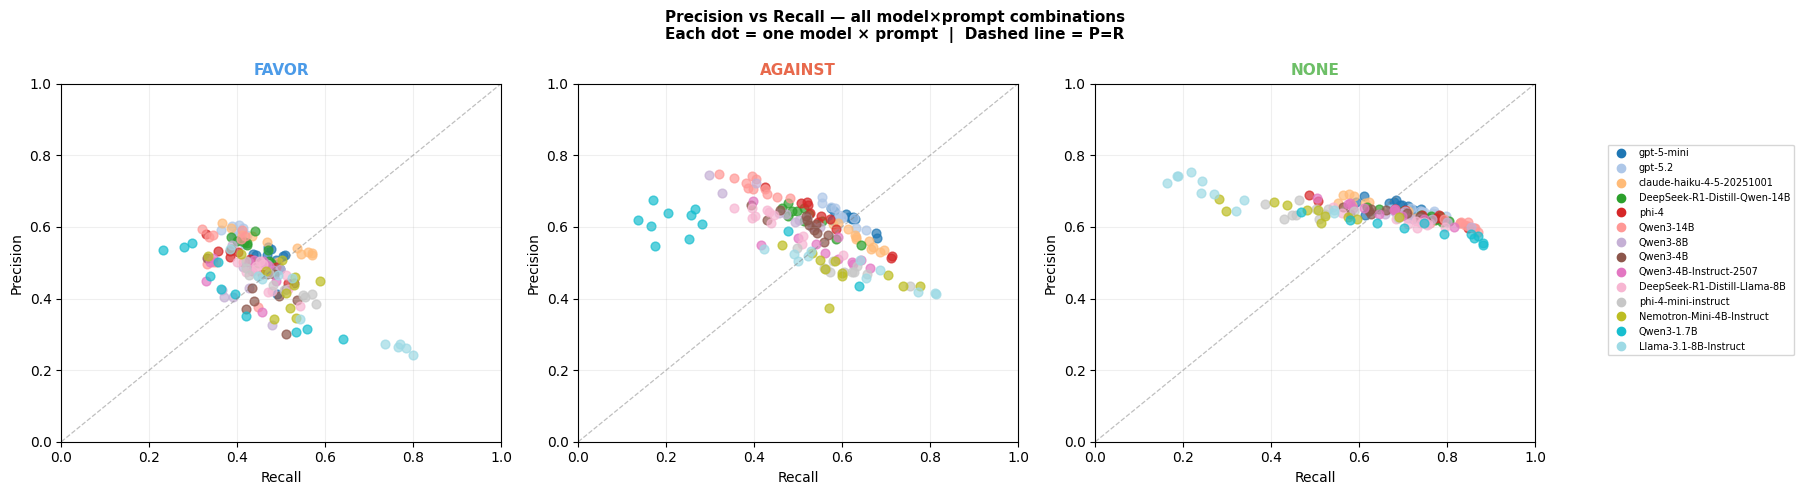

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for col_idx, cls in enumerate(CLASSES):
    ax = axes[col_idx]
    for i, model in enumerate(model_order):
        mdf = llm_df[llm_df["model"] == model]
        ax.scatter(mdf[f"r_{cls.lower()}"], mdf[f"p_{cls.lower()}"],
                   color=cmap(i), alpha=0.7, s=40, label=model)
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=0.9, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(cls, fontsize=11, fontweight="bold", color=CLASS_COLORS[cls])
    ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", color=cmap(i), linewidth=0, markersize=6, label=m)
           for i, m in enumerate(model_order)]
fig.legend(handles=handles, fontsize=7, loc="center right", bbox_to_anchor=(1.0, 0.5), borderaxespad=0.1)
fig.suptitle("Precision vs Recall — all model×prompt combinations\nEach dot = one model × prompt  |  Dashed line = P=R",
             fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

## Step 11: Predicted vs Gold Distribution

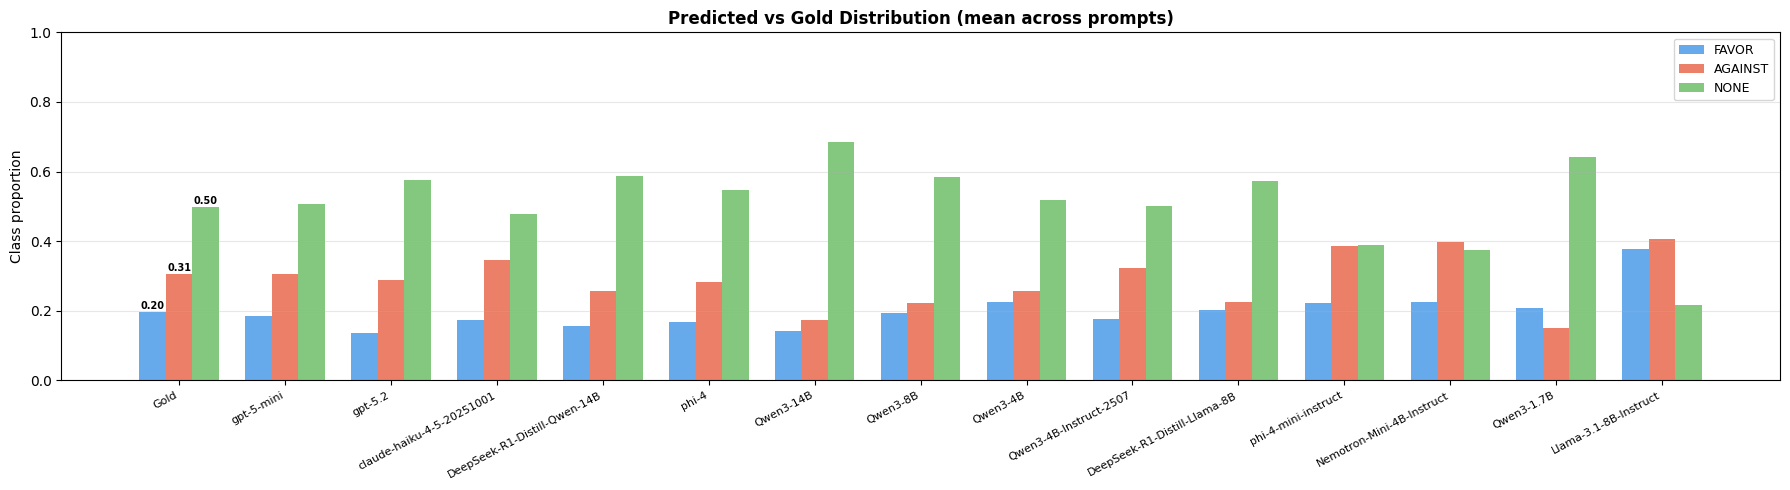

In [11]:
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100: continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({"model":model,"prompt":prompt,
                      "pred_favor":vc.get("FAVOR",0),"pred_against":vc.get("AGAINST",0),"pred_none":vc.get("NONE",0)})

dist_df   = pd.DataFrame(dist_rows)
dist_mean = dist_df.groupby("model")[["pred_favor","pred_against","pred_none"]].mean().reset_index()
gold_row  = pd.DataFrame([{"model":"Gold","pred_favor":GOLD_DIST["FAVOR"],
                            "pred_against":GOLD_DIST["AGAINST"],"pred_none":GOLD_DIST["NONE"]}])
all_order = ["Gold"] + model_order
dist_full = pd.concat([gold_row, dist_mean], ignore_index=True).set_index("model").reindex(all_order)

x_d = np.arange(len(all_order)); bw = 0.25
fig, ax = plt.subplots(figsize=(max(10, len(all_order)*1.2), 5))
for ci, cls in enumerate(CLASSES):
    vals = dist_full[f"pred_{cls.lower()}"].fillna(0).values
    ax.bar(x_d + (ci-1)*bw, vals, width=bw, color=CLASS_COLORS[cls], label=cls, alpha=0.85)
    for bi,v in enumerate(vals):
        if bi==0: ax.text(x_d[bi]+(ci-1)*bw, v+0.008, f"{v:.2f}", ha="center", fontsize=7, fontweight="bold")
ax.set_xticks(x_d); ax.set_xticklabels(all_order, fontsize=8, rotation=28, ha="right")
ax.set_ylim(0,1); ax.set_ylabel("Class proportion"); ax.legend(fontsize=9)
ax.set_title("Predicted vs Gold Distribution (mean across prompts)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 12: Confusion Transition Heatmap

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19558/482550820.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


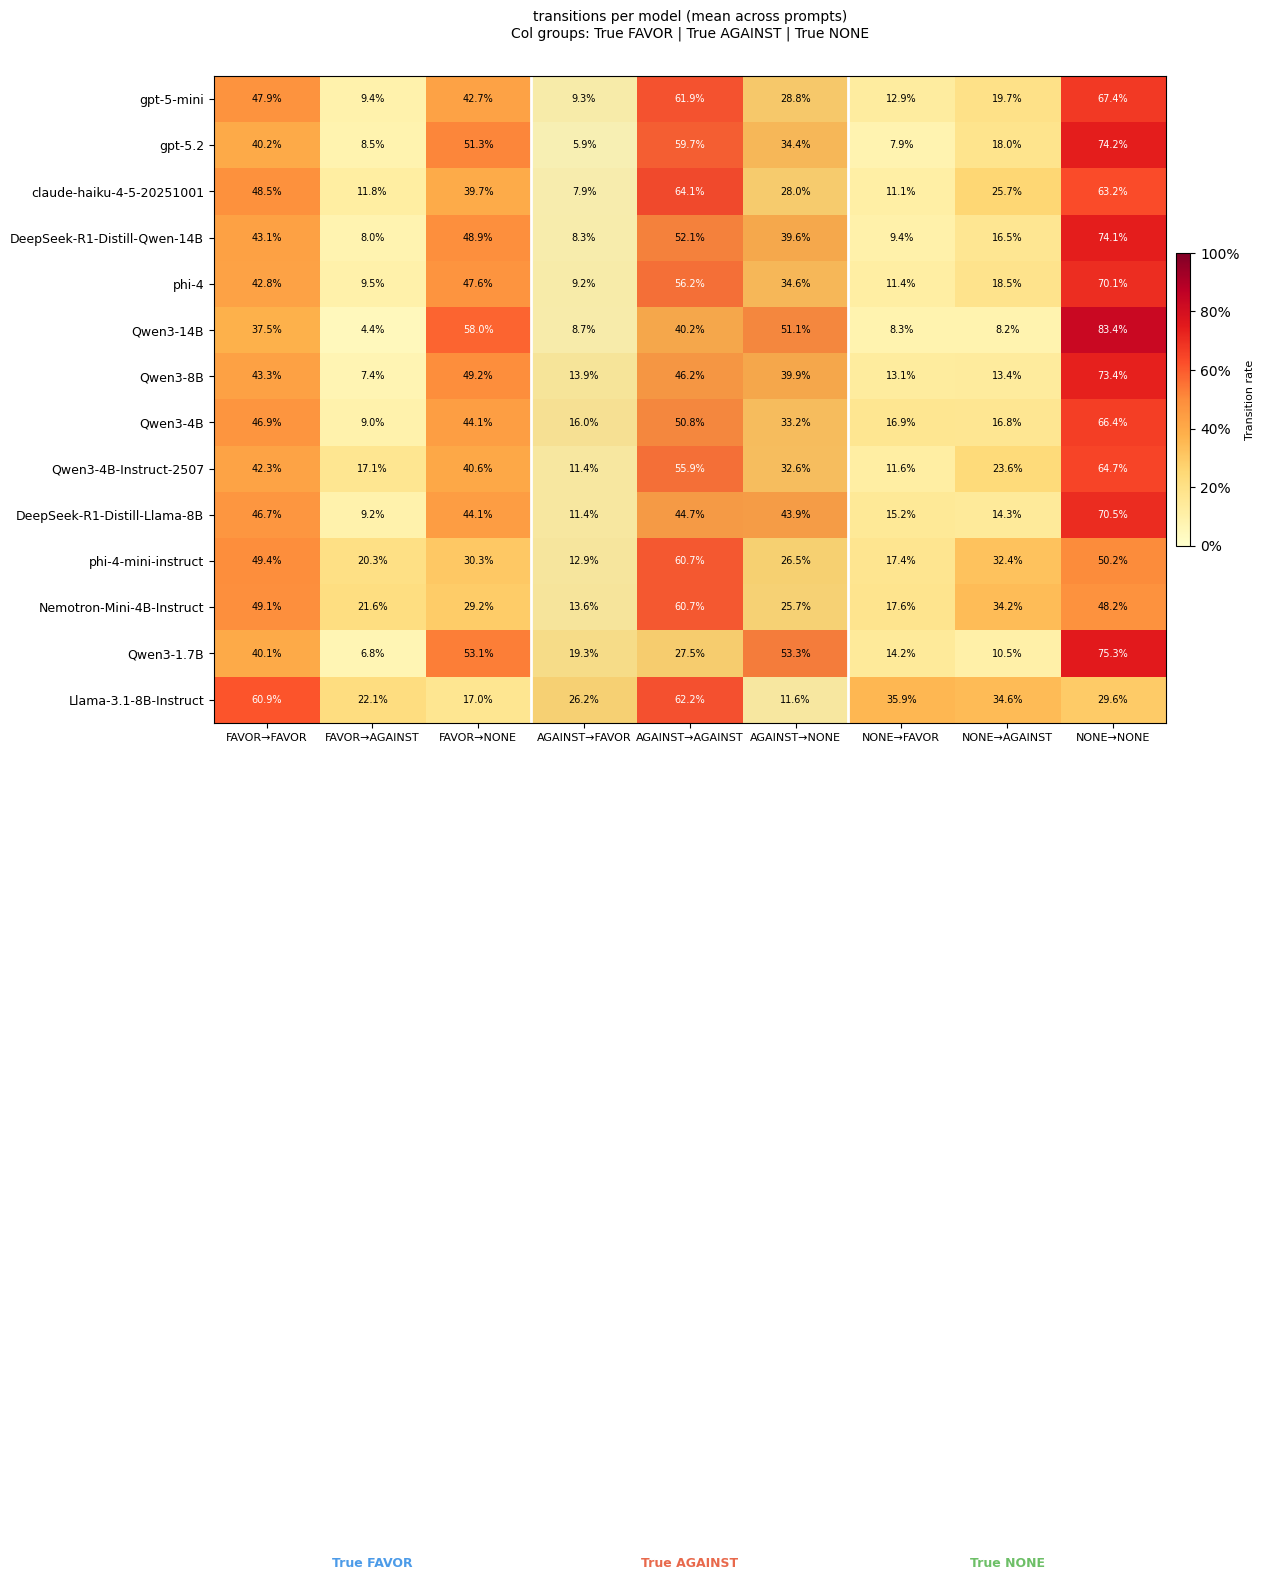

In [12]:
ALL_TRANS = [f"{tc}→{pc}" for tc in CLASSES for pc in CLASSES]
KEY_TRANS  = ["AGAINST→NONE","AGAINST→FAVOR","FAVOR→AGAINST","FAVOR→NONE","NONE→FAVOR","NONE→AGAINST"]

cm_rows_full = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX, ""); parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100: continue
    cm = confusion_matrix(df["original_stance"], df["predicted_stance"], labels=CLASSES).astype(float)
    cm_n = cm / cm.sum(axis=1, keepdims=True)
    row = {"model": model, "prompt": prompt}
    for ri, tc in enumerate(CLASSES):
        for ci, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_n[ri, ci]
    cm_rows_full.append(row)

cm_full_df = pd.DataFrame(cm_rows_full)
# Average per model across all prompts
cm_model = cm_full_df.groupby("model")[ALL_TRANS].mean()
cm_model = cm_model.reindex([m for m in model_order if m in cm_model.index])
hmap = cm_model.values
rlabels = list(cm_model.index)
n_t = len(CLASSES); n_tr = len(CLASSES)

fig, ax = plt.subplots(figsize=(n_t * n_tr * 1.4, max(5, len(rlabels) * 0.6)))
im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
cb = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cb.set_label("Transition rate", fontsize=8)
cb.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for g in range(1, n_t):
    ax.axvline(g * n_tr - 0.5, color="white", linewidth=2)
for di in range(n_t):
    if di % 2 == 1:
        ax.axvspan(di * n_tr - 0.5, (di + 1) * n_tr - 0.5, alpha=0.06, color="grey")

for r in range(hmap.shape[0]):
    for c in range(hmap.shape[1]):
        v = hmap[r, c]
        ax.text(c, r, f"{v*100:.1f}%", ha="center", va="center", fontsize=7,
                color="black" if v < 0.55 else "white")

ax.set_yticks(range(len(rlabels))); ax.set_yticklabels(rlabels, fontsize=9)
ax.set_xticks(range(len(ALL_TRANS)))
ax.set_xticklabels(ALL_TRANS, fontsize=8)

for gi, tc in enumerate(CLASSES):
    mid = gi * n_tr + (n_tr - 1) / 2
    ax.text(mid, -1.3, f"True {tc}", ha="center", va="center", fontsize=9,
            fontweight="bold", color=CLASS_COLORS[tc],
            transform=ax.get_xaxis_transform())

ax.set_title("transitions per model (mean across prompts)\nCol groups: True FAVOR | True AGAINST | True NONE",
             fontsize=10, pad=28)
plt.tight_layout()
plt.show()

Models included: ['gpt-5-mini', 'gpt-5.2', 'claude-haiku-4-5-20251001', 'DeepSeek-R1-Distill-Qwen-14B', 'phi-4', 'Qwen3-14B', 'Qwen3-8B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'DeepSeek-R1-Distill-Llama-8B', 'phi-4-mini-instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Llama-3.1-8B-Instruct']


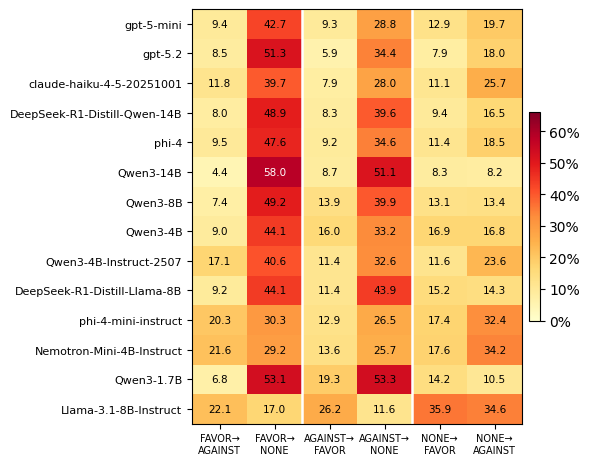

In [13]:
ERROR_TRANS = ["FAVOR→AGAINST", "FAVOR→NONE", "AGAINST→FAVOR", "AGAINST→NONE", "NONE→FAVOR", "NONE→AGAINST"]

# NOTE: cm_model as computed earlier in this notebook is missing claude-haiku-4-5-20251001 —
# confirm the model list below before using this for the paper.
print("Models included:", list(cm_model.index))

data_m6 = cm_model[ERROR_TRANS].values

fig, ax = plt.subplots(figsize=(6.0, max(3.2, len(cm_model) * 0.34)))
vmax = 0.660  # shared color scale across SemEval/EZStance/MTCSD 6-col figures
im = ax.imshow(data_m6, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)

ax.set_xticks(range(len(ERROR_TRANS)))
ax.set_xticklabels([t.replace("→", "→\n") for t in ERROR_TRANS], fontsize=7)
ax.set_yticks(range(len(cm_model)))
ax.set_yticklabels(cm_model.index, fontsize=8)

for sep in [1.5, 3.5]:
    ax.axvline(sep, color="white", linewidth=1.8)

for i in range(data_m6.shape[0]):
    for j in range(data_m6.shape[1]):
        v = data_m6[i, j]
        ax.text(j, i, f"{v*100:.1f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > 0.55 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.savefig("mtcsd_confusion_matrix_6col.png", dpi=400, bbox_inches="tight")
plt.show()


## Step 13: Model Ranking Table — 3-class F1

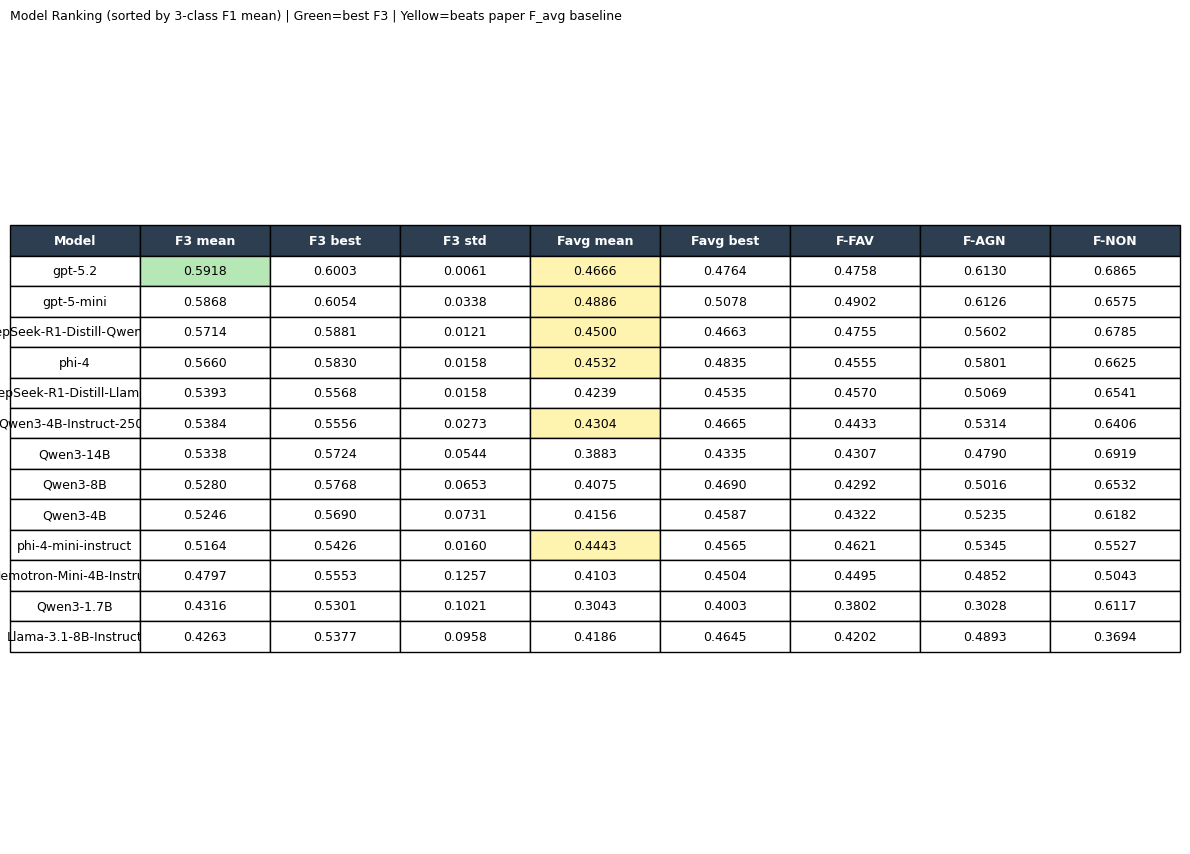

In [13]:
ranking = (
    llm_df.groupby("model")
    .agg(mean_f3=("3class_macro_f1","mean"), best_f3=("3class_macro_f1","max"),
         std_f3=("3class_macro_f1","std"),
         mean_f_avg=("f_avg","mean"), best_f_avg=("f_avg","max"),
         f_favor=("f_favor","mean"), f_against=("f_against","mean"), f_none=("f_none","mean"))
    .reset_index().sort_values("mean_f3", ascending=False).reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, max(3, len(ranking)*0.55 + 1.5)))
ax.axis("off")
cols = ["Model","F3 mean","F3 best","F3 std","Favg mean","Favg best","F-FAV","F-AGN","F-NON"]
data = [[r["model"], f"{r['mean_f3']:.4f}", f"{r['best_f3']:.4f}", f"{r['std_f3']:.4f}",
         f"{r['mean_f_avg']:.4f}", f"{r['best_f_avg']:.4f}",
         f"{r['f_favor']:.4f}", f"{r['f_against']:.4f}", f"{r['f_none']:.4f}"]
        for _,r in ranking.iterrows()]

BEST_F3   = ranking["mean_f3"].max()
REF_FAVG  = PAPER_FAVG["TTS (best indiv.)"]
cell_colors = []
for _,r in ranking.iterrows():
    is_best = abs(r["mean_f3"]-BEST_F3) < 1e-6
    beats   = r["mean_f_avg"] >= REF_FAVG
    c_f3  = "#b6e8b6" if is_best else "#ffffff"
    c_fav = "#fff3b0" if beats  else "#ffffff"
    cell_colors.append(["#ffffff", c_f3, "#ffffff", "#ffffff", c_fav, "#ffffff",
                        "#ffffff","#ffffff","#ffffff"])

tbl = ax.table(cellText=data, colLabels=cols, cellLoc="center", loc="center",
               cellColours=cell_colors)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
for j in range(len(cols)):
    tbl[0,j].set_facecolor("#2c3e50")
    tbl[0,j].set_text_props(color="white", fontweight="bold")
ax.set_title("Model Ranking (sorted by 3-class F1 mean) | Green=best F3 | Yellow=beats paper F_avg baseline",
             fontsize=9, pad=10, loc="left")
plt.tight_layout(); plt.show()

## Step 14: Prompt Sensitivity — 3-class F1

                       model  mean_f3   std_f3  range_f3     best worst
                     gpt-5.2 0.591765 0.006099  0.017991       6R Scale
                  gpt-5-mini 0.586793 0.033786  0.112391       9R Scale
DeepSeek-R1-Distill-Qwen-14B 0.571432 0.012063  0.046619       9R Scale
                       phi-4 0.566049 0.015805  0.052549      12R Scale
DeepSeek-R1-Distill-Llama-8B 0.539319 0.015779  0.046325      CoT Scale
      Qwen3-4B-Instruct-2507 0.538403 0.027251  0.094161 Task-def Scale
                   Qwen3-14B 0.533838 0.054440  0.191910      12R Scale
                    Qwen3-8B 0.528006 0.065313  0.230063      15R Scale
                    Qwen3-4B 0.524630 0.073146  0.255222       3R Scale
         phi-4-mini-instruct 0.516437 0.015986  0.047298 Task-def   CoT
   Nemotron-Mini-4B-Instruct 0.479664 0.125690  0.445832      15R Scale
                  Qwen3-1.7B 0.431580 0.102077  0.390471      CoT Scale
       Llama-3.1-8B-Instruct 0.426298 0.095827  0.351473  Defaul

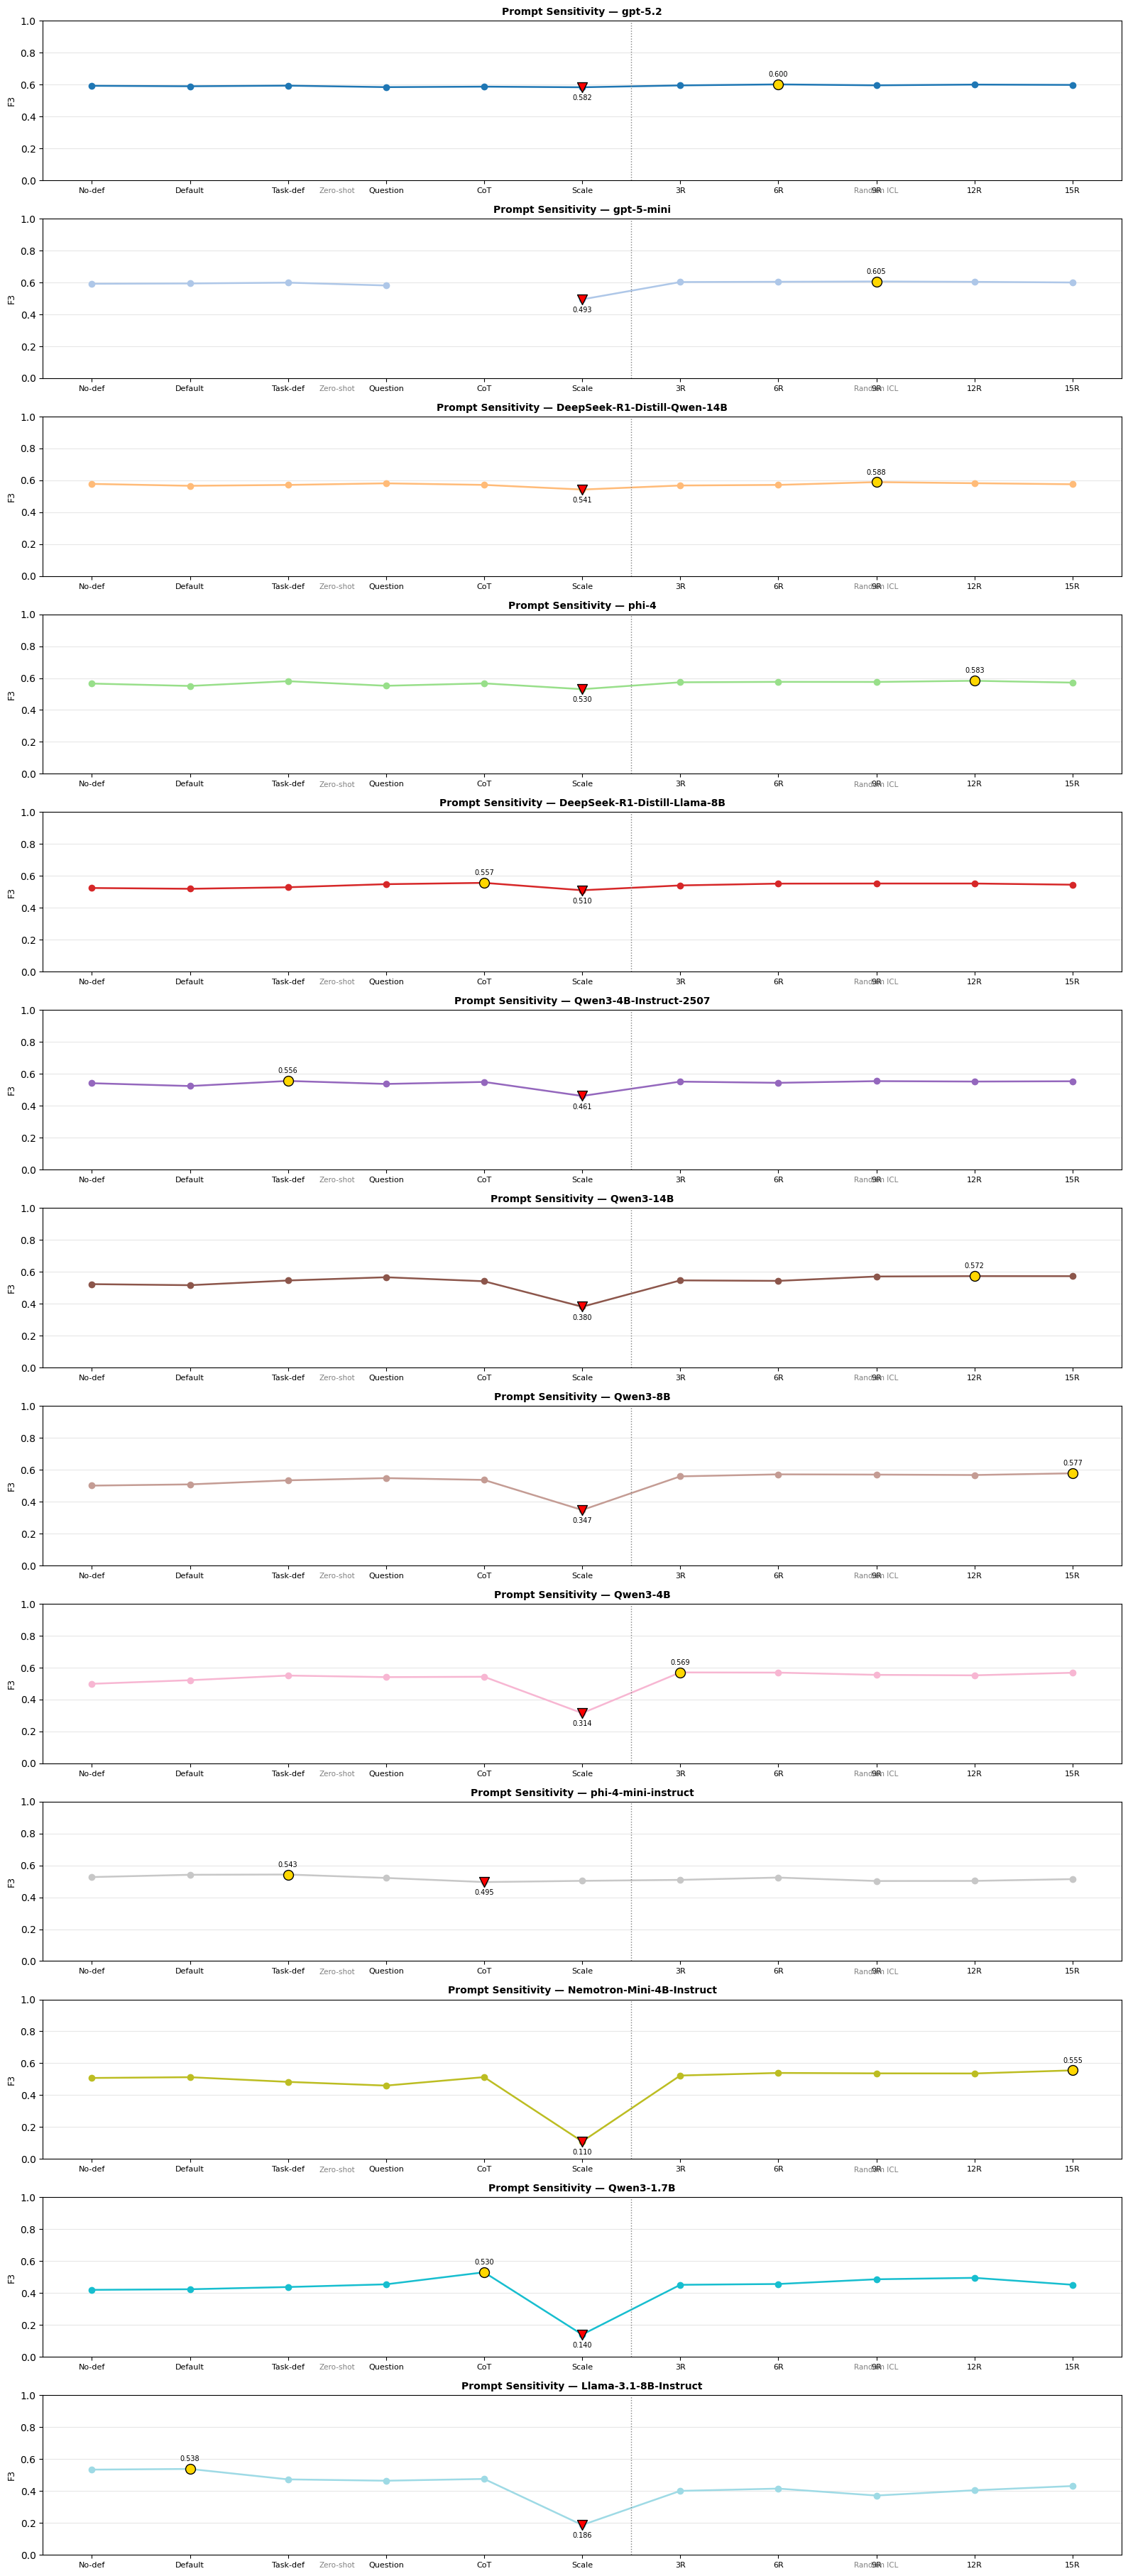

In [14]:
sens_rows = []
for model, grp in llm_df.groupby("model"):
    bi = grp["3class_macro_f1"].idxmax(); wi = grp["3class_macro_f1"].idxmin()
    sens_rows.append({"model":model, "mean_f3":grp["3class_macro_f1"].mean(),
                      "std_f3":grp["3class_macro_f1"].std(),
                      "range_f3":grp["3class_macro_f1"].max()-grp["3class_macro_f1"].min(),
                      "best":PROMPT_LABELS.get(grp.loc[bi,"prompt"],grp.loc[bi,"prompt"]),
                      "worst":PROMPT_LABELS.get(grp.loc[wi,"prompt"],grp.loc[wi,"prompt"])})
print(pd.DataFrame(sens_rows).sort_values("mean_f3",ascending=False).to_string(index=False))

n_m = len(model_order)
fig, axes = plt.subplots(n_m, 1, figsize=(max(16,len(available_prompts)*1.1), n_m*2.8), sharey=True)
if n_m==1: axes=[axes]
for ai, model in enumerate(model_order):
    ax  = axes[ai]
    mdf = llm_df[llm_df["model"]==model].set_index("prompt")
    y   = [mdf.loc[p,"3class_macro_f1"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=6, color=cmap(ai), label=model)
    valid = [(xi,yi) for xi,yi in zip(x_pos,y) if not np.isnan(yi)]
    if valid:
        bx,by = max(valid,key=lambda t:t[1]); wx,wy = min(valid,key=lambda t:t[1])
        ax.scatter([bx],[by],s=100,color="gold",edgecolors="black",zorder=5)
        ax.scatter([wx],[wy],s=100,color="red",edgecolors="black",marker="v",zorder=5)
        ax.annotate(f"{by:.3f}",(bx,by),textcoords="offset points",xytext=(0,8),ha="center",fontsize=7)
        ax.annotate(f"{wy:.3f}",(wx,wy),textcoords="offset points",xytext=(0,-13),ha="center",fontsize=7)
    add_icl_sep(ax)
    ax.set_ylim(0,1); ax.set_xticks(x_pos); ax.set_xticklabels(x_labels,fontsize=8)
    ax.set_ylabel("F3",fontsize=9)
    ax.set_title(f"Prompt Sensitivity — {model}",fontsize=10,fontweight="bold")
    ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

## Step 15: F3 by Prompt Family

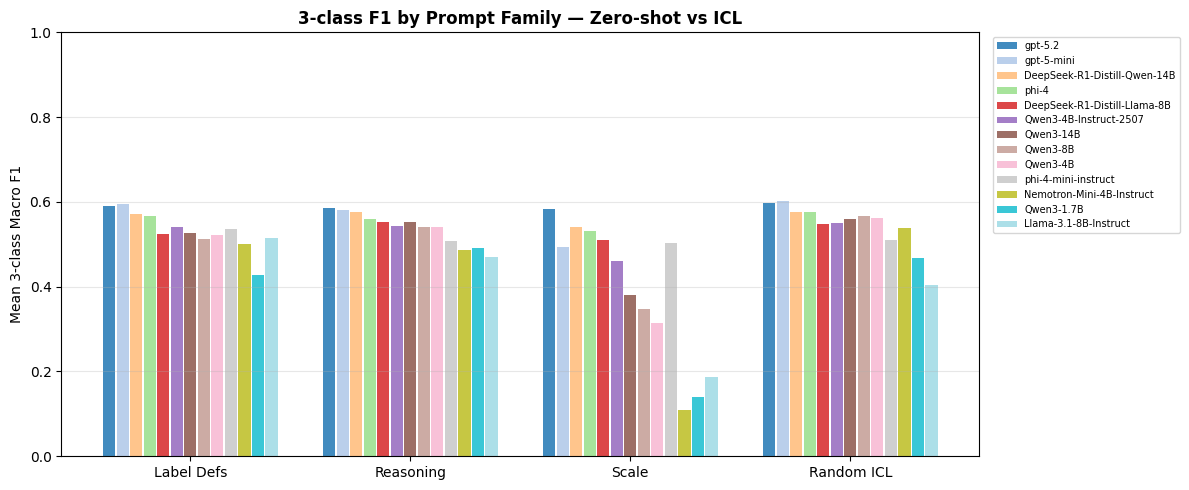

In [15]:
FAMILIES = OrderedDict([
    ("Label Defs",  {"prompts":["default_no_label_definitions","default","task_definition"], "color":"#E8694C"}),
    ("Reasoning",   {"prompts":["cot","question"],                                          "color":"#984ea3"}),
    ("Scale",       {"prompts":["task_definition_scale"],                                   "color":"#999999"}),
    ("Random ICL",  {"prompts":["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"], "color":"#4C9BE8"}),
])
family_names = list(FAMILIES.keys())
n_fam = len(family_names); x_fam = np.arange(n_fam)
n_mf  = len(model_order);  bw = 0.8/max(n_mf,1)

fig, ax = plt.subplots(figsize=(max(12,n_fam*3), 5))
for mi, model in enumerate(model_order):
    mdf = llm_df[llm_df["model"]==model]
    means_fam = [mdf[mdf["prompt"].isin([p for p in fam["prompts"] if p in mdf["prompt"].values])]["3class_macro_f1"].mean()
                 if any(p in mdf["prompt"].values for p in fam["prompts"]) else float("nan")
                 for fam in FAMILIES.values()]
    ax.bar(x_fam + (mi-(n_mf-1)/2)*bw, means_fam, width=bw*0.9, color=cmap(mi), label=model, alpha=0.85)
ax.set_xticks(x_fam); ax.set_xticklabels(family_names, fontsize=10)
ax.set_ylim(0,1); ax.set_ylabel("Mean 3-class Macro F1", fontsize=10)
ax.set_title("3-class F1 by Prompt Family — Zero-shot vs ICL", fontsize=12, fontweight="bold")
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 16: Per-target Analysis — Label Distribution + Per-class F1

4-row × 5-column grid:  
- **Row 0**: Gold label distribution per target  
- **Rows 1–3**: FAVOR / AGAINST / NONE F1 per model (best prompt), per target

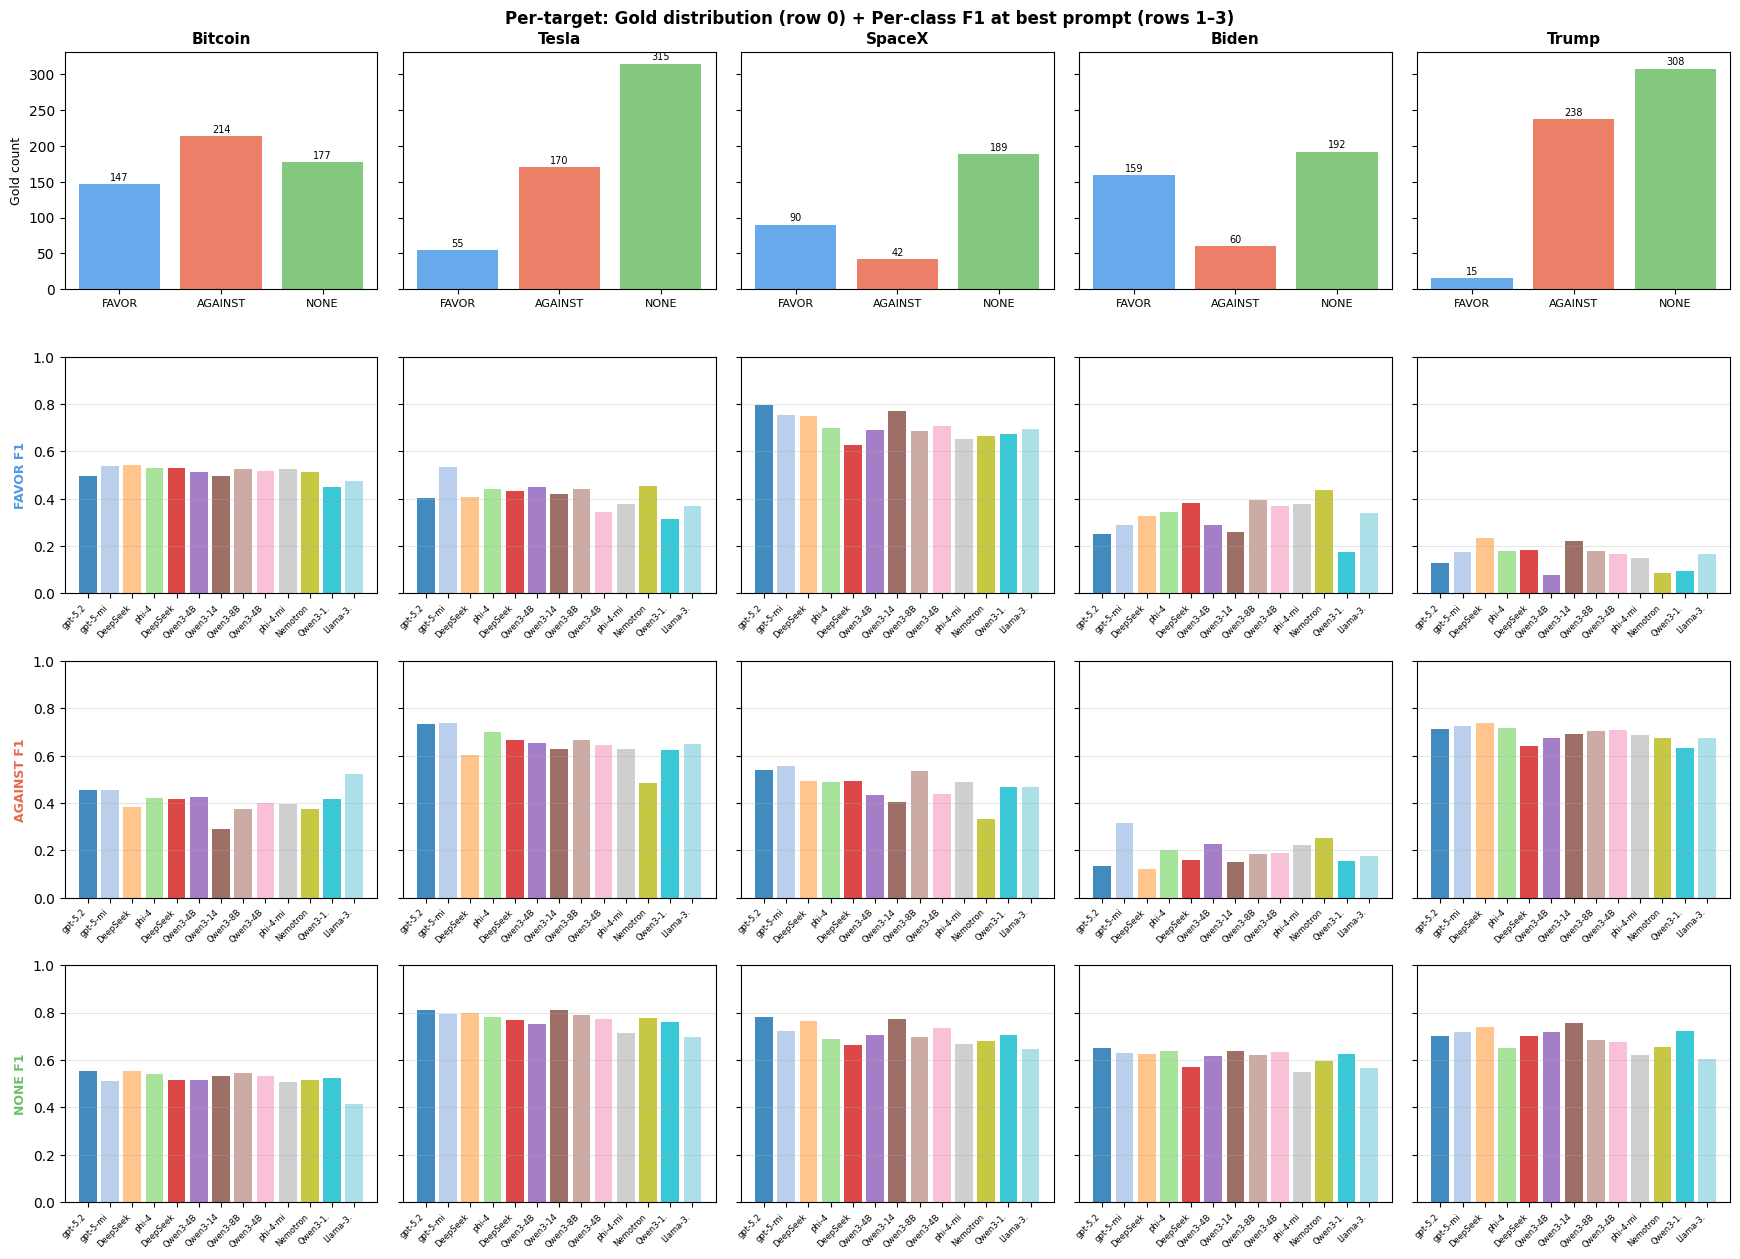

In [16]:
gold_df = pd.read_csv(GOLD_PATH)
gold_df["gold"] = gold_df["stance_label"].astype(str).str.upper().str.strip()
gold_df["id"]   = gold_df["id"].astype(str)

# Load per-target predictions for all experiments
tgt_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    preds["id"]   = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_df[["id","gold","query"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]
    for target in TARGET_ORDER:
        sub = merged[merged["query"]==target]
        if len(sub)==0: continue
        _,_,f,_ = precision_recall_fscore_support(sub["gold"],sub["pred"],labels=CLASSES,average=None,zero_division=0)
        tgt_rows.append({"model":model,"prompt":prompt,"target":target,
                         "f3":f.mean(),"f_favor":f[0],"f_against":f[1],"f_none":f[2],"n":len(sub)})

tgt_df = pd.DataFrame(tgt_rows)

# Best prompt per model (by overall F3)
best_prompt = {m: llm_df[llm_df["model"]==m].sort_values("3class_macro_f1").iloc[-1]["prompt"]
               for m in model_order}

# ── Plot ─────────────────────────────────────────────────────────────────────
n_rows_plot = 4; n_cols_plot = len(TARGET_ORDER)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(n_cols_plot*3.5, n_rows_plot*3.2), sharey="row")

for ci, target in enumerate(TARGET_ORDER):
    # Row 0: gold label distribution
    ax = axes[0,ci]
    sub_gold = gold_df[gold_df["query"]==target]
    counts   = sub_gold["gold"].value_counts().reindex(CLASSES, fill_value=0)
    ax.bar(CLASSES, counts.values, color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.85)
    for xi,v in enumerate(counts.values):
        ax.text(xi, v+5, str(v), ha="center", fontsize=7)
    ax.set_title(target, fontsize=11, fontweight="bold")
    if ci==0: ax.set_ylabel("Gold count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

    # Rows 1–3: per-class F1 at best prompt per model
    for ri, cls in enumerate(CLASSES):
        ax = axes[ri+1, ci]
        f_col = f"f_{cls.lower()}"
        x_m = np.arange(len(model_order))
        for mi, model in enumerate(model_order):
            bp  = best_prompt[model]
            sub = tgt_df[(tgt_df["model"]==model)&(tgt_df["prompt"]==bp)&(tgt_df["target"]==target)]
            val = sub[f_col].values[0] if len(sub)>0 else float("nan")
            ax.bar(x_m[mi], val, color=cmap(mi), alpha=0.85)
        ax.set_xticks(x_m)
        ax.set_xticklabels([m[:8] for m in model_order], rotation=45, ha="right", fontsize=6)
        ax.set_ylim(0,1)
        if ci==0:
            ax.set_ylabel(f"{cls} F1", fontsize=9, color=CLASS_COLORS[cls], fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-target: Gold distribution (row 0) + Per-class F1 at best prompt (rows 1–3)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 17: Per-target Overall F3 — Table + Chart

Target       F3 mean   F3 std   F-FAV   F-AGN   F-NON
─────────────────────────────────────────────────────
Bitcoin       0.4579   0.0603  0.4971  0.3867  0.4900
Tesla         0.5625   0.0983  0.3754  0.5981  0.7139
SpaceX        0.5754   0.0912  0.6609  0.4232  0.6421
Biden         0.3566   0.0373  0.3340  0.1698  0.5659
Trump         0.4691   0.0972  0.1469  0.6353  0.6252


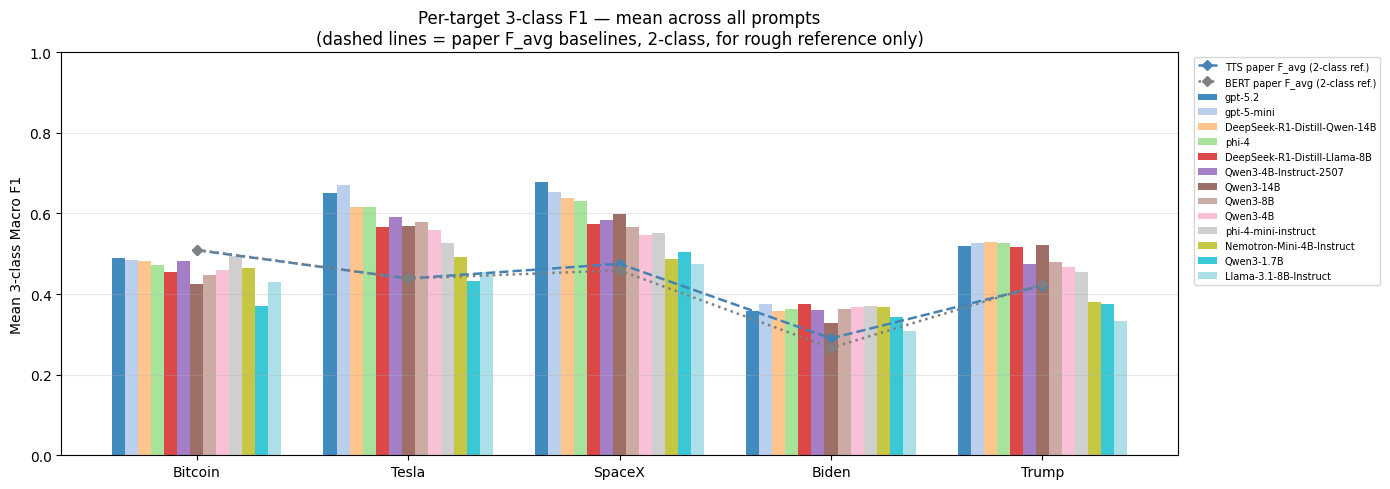

In [17]:
tgt_mean = tgt_df.groupby(["model","target"])[["f3","f_favor","f_against","f_none"]].mean().reset_index()

# Table
tbl_t = tgt_df.groupby("target").agg(mean_f3=("f3","mean"),std_f3=("f3","std"),
            mean_ffav=("f_favor","mean"),mean_fagn=("f_against","mean"),mean_fnon=("f_none","mean"))\
              .reindex(TARGET_ORDER).reset_index()
hdr = f"{'Target':<10} {'F3 mean':>9} {'F3 std':>8} {'F-FAV':>7} {'F-AGN':>7} {'F-NON':>7}"
print(hdr); print("─"*len(hdr))
for _,r in tbl_t.iterrows():
    print(f"{r['target']:<10} {r['mean_f3']:>9.4f} {r['std_f3']:>8.4f} "
          f"{r['mean_ffav']:>7.4f} {r['mean_fagn']:>7.4f} {r['mean_fnon']:>7.4f}")

# Chart
x_t = np.arange(len(TARGET_ORDER))
width = 0.8/max(len(model_order),1)
offsets = np.linspace(-(0.8-width)/2,(0.8-width)/2,len(model_order))

fig, ax = plt.subplots(figsize=(14,5))
for mi,model in enumerate(model_order):
    mdf = tgt_mean[tgt_mean["model"]==model].set_index("target")
    y   = [mdf.loc[t,"f3"] if t in mdf.index else np.nan for t in TARGET_ORDER]
    ax.bar(x_t+offsets[mi], y, width=width, label=model, color=cmap(mi), alpha=0.85)

# Paper per-target F_avg as reference lines (labelled as 2-class)
for bl_name, bl_col, bl_ls in [("TTS","steelblue","--"),("BERT","grey",":")]:
    bl_vals = [PAPER_PER_TARGET[bl_name].get(t,np.nan) for t in TARGET_ORDER]
    ax.plot(x_t, bl_vals, color=bl_col, linestyle=bl_ls, linewidth=1.8,
            marker="D", markersize=5, label=f"{bl_name} paper F_avg (2-class ref.)")

ax.set_xticks(x_t); ax.set_xticklabels(TARGET_ORDER, fontsize=10)
ax.set_ylim(0,1); ax.set_ylabel("Mean 3-class Macro F1")
ax.set_title("Per-target 3-class F1 — mean across all prompts\n"
             "(dashed lines = paper F_avg baselines, 2-class, for rough reference only)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 18: Per-target Confusion Transition Heatmap

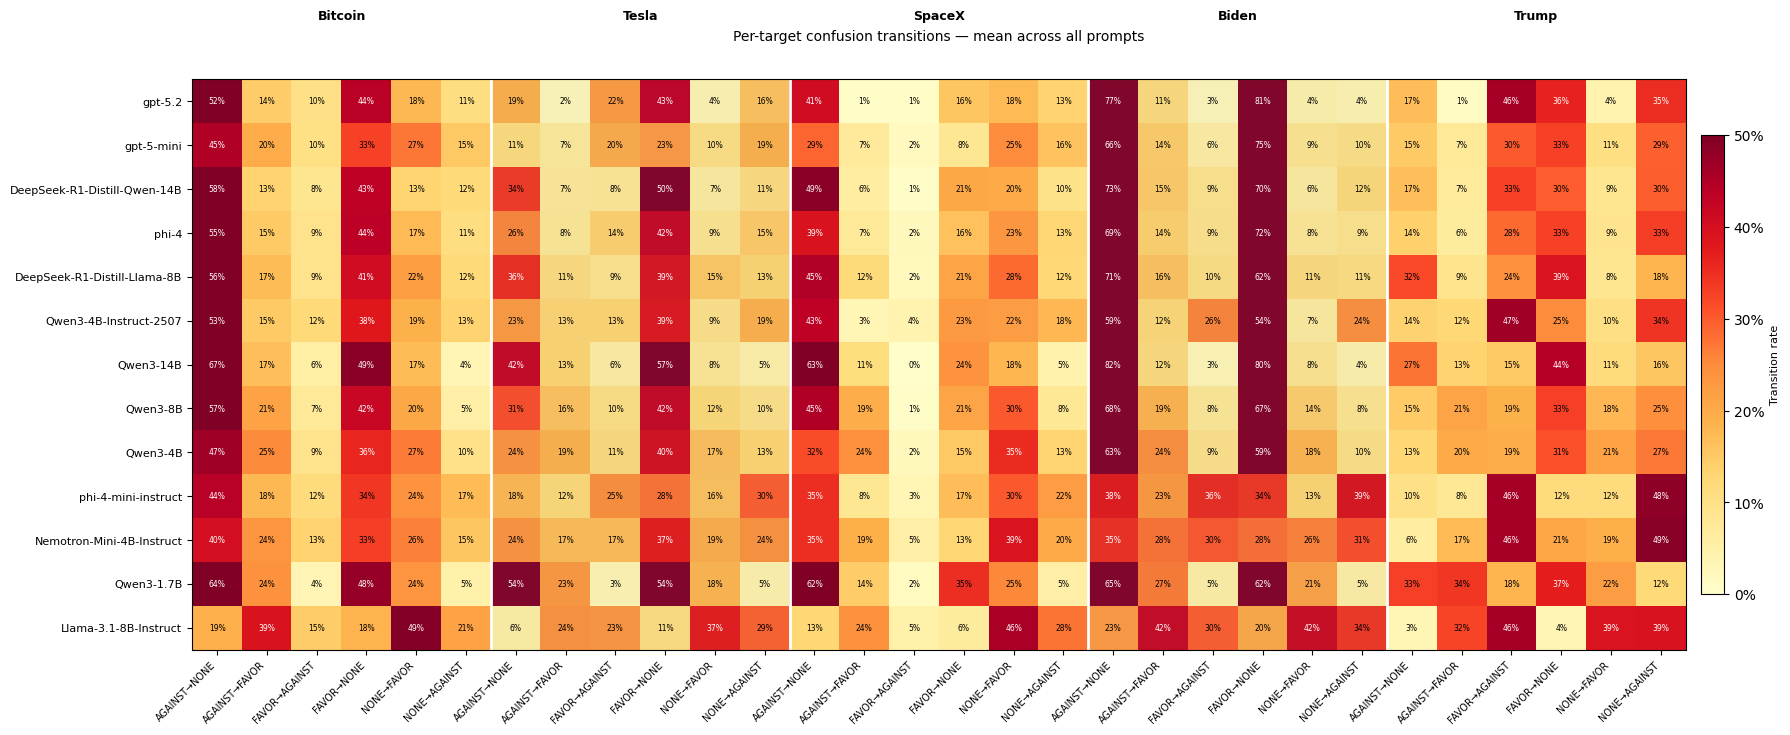

In [18]:
ct_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model,prompt = parts
    if prompt not in PROMPT_ORDER: continue
    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    preds["id"]   = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_df[["id","gold","query"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]
    for target in TARGET_ORDER:
        sub = merged[merged["query"]==target]
        if len(sub)<5: continue
        cm = confusion_matrix(sub["gold"],sub["pred"],labels=CLASSES)
        cm_p = cm/cm.sum(axis=1,keepdims=True).clip(min=1)
        entry = {"model":model,"prompt":prompt,"target":target}
        for tc,pc in [("AGAINST","NONE"),("AGAINST","FAVOR"),("FAVOR","AGAINST"),
                      ("FAVOR","NONE"),("NONE","FAVOR"),("NONE","AGAINST")]:
            entry[f"{tc}→{pc}"] = cm_p[CLASSES.index(tc),CLASSES.index(pc)]
        ct_rows.append(entry)

ct_df  = pd.DataFrame(ct_rows)
ct_mean= ct_df.groupby(["model","target"])[KEY_TRANS].mean().reset_index()

n_t=len(TARGET_ORDER); n_tr=len(KEY_TRANS); n_cols=n_t*n_tr; n_m_ct=len(model_order)
mat = np.full((n_m_ct,n_cols), np.nan)
for ri,model in enumerate(model_order):
    for di,target in enumerate(TARGET_ORDER):
        sub = ct_mean[(ct_mean["model"]==model)&(ct_mean["target"]==target)]
        if sub.empty: continue
        for ti,trans in enumerate(KEY_TRANS):
            mat[ri, di*n_tr+ti] = sub.iloc[0][trans]

fig,ax = plt.subplots(figsize=(max(18,n_cols*0.6), max(4,n_m_ct*0.42+2)))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5)
ax.set_xticks(range(n_cols)); ax.set_xticklabels(KEY_TRANS*n_t, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_m_ct)); ax.set_yticklabels(model_order, fontsize=8)
for di,target in enumerate(TARGET_ORDER):
    ax.text(di*n_tr+(n_tr-1)/2, -1.8, target, ha="center", va="bottom", fontsize=9, fontweight="bold")
    if di>0: ax.axvline(di*n_tr-0.5, color="white", linewidth=2)
for r in range(n_m_ct):
    for c in range(n_cols):
        v=mat[r,c]
        if not np.isnan(v):
            ax.text(c,r,f"{v:.0%}",ha="center",va="center",fontsize=5.5,
                    color="black" if v<0.35 else "white")
for di in range(n_t):
    if di%2==1: ax.axvspan(di*n_tr-0.5,(di+1)*n_tr-0.5,alpha=0.06,color="grey")
cb = fig.colorbar(im,ax=ax,fraction=0.015,pad=0.01)
cb.set_label("Transition rate",fontsize=8)
cb.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Per-target confusion transitions — mean across all prompts", fontsize=10, pad=28)
plt.tight_layout(); plt.show()